**Group Members - Pratham Patel, Suhana Matta, Yuvraj Modh, Deepak Kumar, Muhammad Shazain Farid**

**Data Cleaning**

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Final Project.csv")

id_vars = ['company_name', 'ticker']
value_vars = [col for col in df.columns if col not in id_vars]

df_long = df.melt(
    id_vars=id_vars,
    value_vars=value_vars,
    var_name='date_metric',
    value_name='value'
)

df_long[['Date', 'Metric']] = df_long['date_metric'].str.rsplit('_', n=1, expand=True)
df_long['Metric'] = df_long['Metric'].str.title()
df_long.drop(columns='date_metric', inplace=True)

df_cleaned = df_long.pivot_table(
    index=['company_name', 'ticker', 'Date'],
    columns='Metric',
    values='value'
).reset_index()
df_cleaned.rename(columns={'Closing': 'Close', 'Opening': 'Open', 'Volume': 'Volume'}, inplace=True)

df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], format='%d-%m-%Y')

df_cleaned.dropna(inplace=True)

df_cleaned['Daily_Change'] = df_cleaned['Close'] - df_cleaned['Open']
df_cleaned['Daily_Percent_Change'] = (df_cleaned['Daily_Change'] / df_cleaned['Open']) * 100

df_cleaned.to_csv("cleaned_stock_data.csv", index=False)

**Insight 1 - Volatility & Risk Management**

/tmp/ipython-input-709939523.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=volatility.index, y=volatility.values, palette="Reds_d")


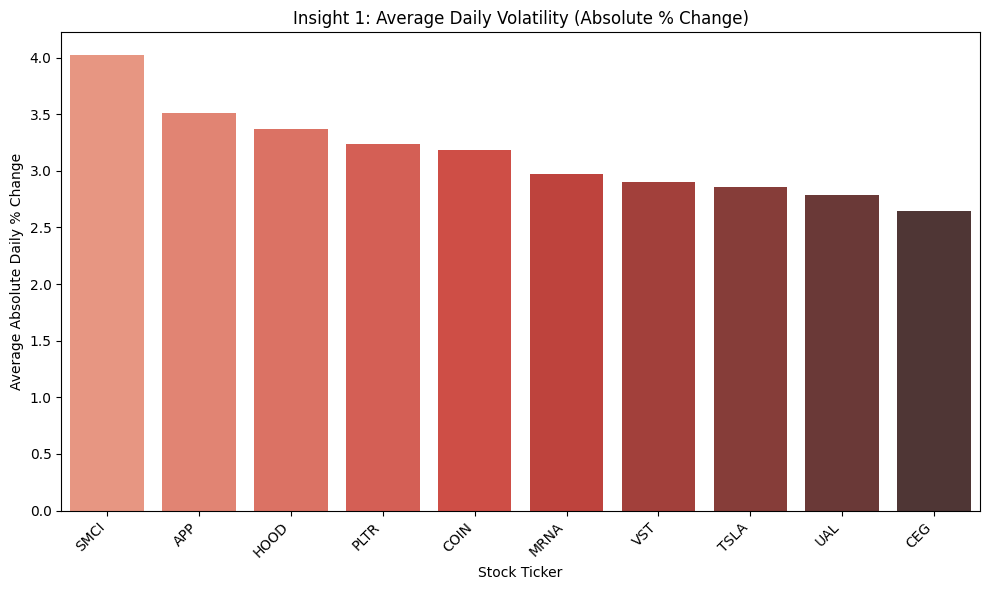

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_cleaned = pd.read_csv("cleaned_stock_data.csv")

volatility = df_cleaned.groupby('ticker')['Daily_Percent_Change'].apply(lambda x: np.mean(np.abs(x))).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=volatility.index, y=volatility.values, palette="Reds_d")
plt.title('Insight 1: Average Daily Volatility (Absolute % Change)')
plt.xlabel('Stock Ticker')
plt.ylabel('Average Absolute Daily % Change')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight 2 - Liquidity & Trading Strategy**

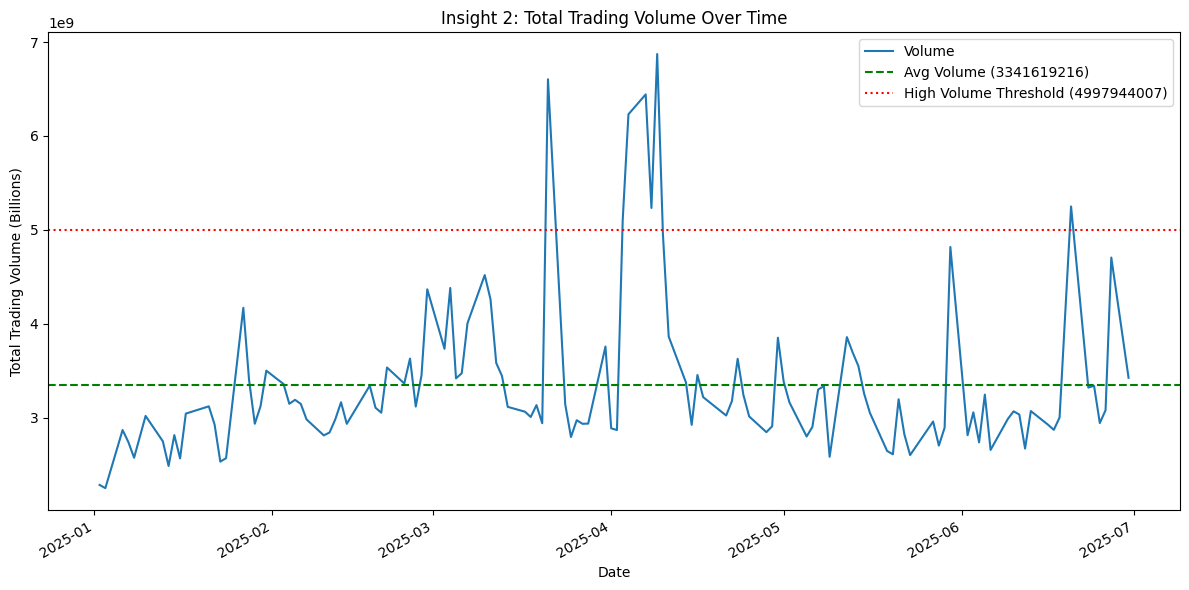

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df_cleaned = pd.read_csv("cleaned_stock_data.csv")
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

daily_volume = df_cleaned.groupby('Date')['Volume'].sum()

avg_volume = daily_volume.mean()
std_volume = daily_volume.std()
abnormal_threshold = avg_volume + (2 * std_volume)

high_volume_dates = daily_volume[daily_volume > abnormal_threshold].index.strftime('%Y-%m-%d').tolist()

plt.figure(figsize=(12, 6))
daily_volume.plot(kind='line')
plt.axhline(avg_volume, color='green', linestyle='--', label=f'Avg Volume ({avg_volume:.0f})')
plt.axhline(abnormal_threshold, color='red', linestyle=':', label=f'High Volume Threshold ({abnormal_threshold:.0f})')
plt.title('Insight 2: Total Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Total Trading Volume (Billions)')
plt.legend()
plt.tight_layout()
plt.show()


**Insight 3 - Performance vs. Market Trend**

/tmp/ipython-input-82609709.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_performers.index, y=top_performers.values, palette="Blues_d")


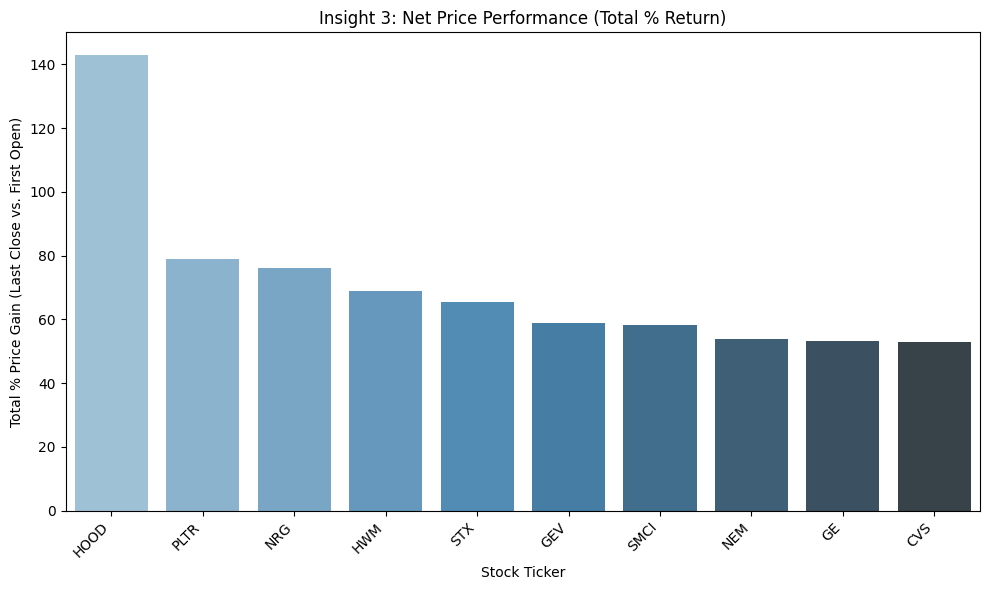

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_cleaned = pd.read_csv("cleaned_stock_data.csv")
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

first_prices = df_cleaned.sort_values('Date').drop_duplicates('ticker', keep='first')[['ticker', 'Open']].set_index('ticker')
last_prices = df_cleaned.sort_values('Date').drop_duplicates('ticker', keep='last')[['ticker', 'Close']].set_index('ticker')

net_performance = last_prices['Close'] - first_prices['Open']
net_performance_percent = (net_performance / first_prices['Open']) * 100
top_performers = net_performance_percent.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_performers.index, y=top_performers.values, palette="Blues_d")
plt.title('Insight 3: Net Price Performance (Total % Return)')
plt.xlabel('Stock Ticker')
plt.ylabel('Total % Price Gain (Last Close vs. First Open)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()